# Task 3: Data Visualization

## Objective

To transform restaurant data into meaningful visualizations using
Python, Matplotlib, and Seaborn.

The visualizations are designed to identify patterns in restaurant
ratings, pricing, locations, cuisines, and customer engagement.

## Tools Used

- Python
- Pandas
- Matplotlib
- Seaborn
- Google Colab

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
url = "https://raw.githubusercontent.com/You-sha/Restaurant-Ratings-Prediction/master/zomato.csv"

df = pd.read_csv(url, encoding="ISO-8859-1")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 9551
Columns: 21


In [3]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [4]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (9551, 21)

Missing values:
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

Column names:
['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']


In [5]:
visual_df = df[df["Aggregate rating"] > 0].copy()

print("Original records:", len(df))
print("Records with valid ratings:", len(visual_df))

Original records: 9551
Records with valid ratings: 7403


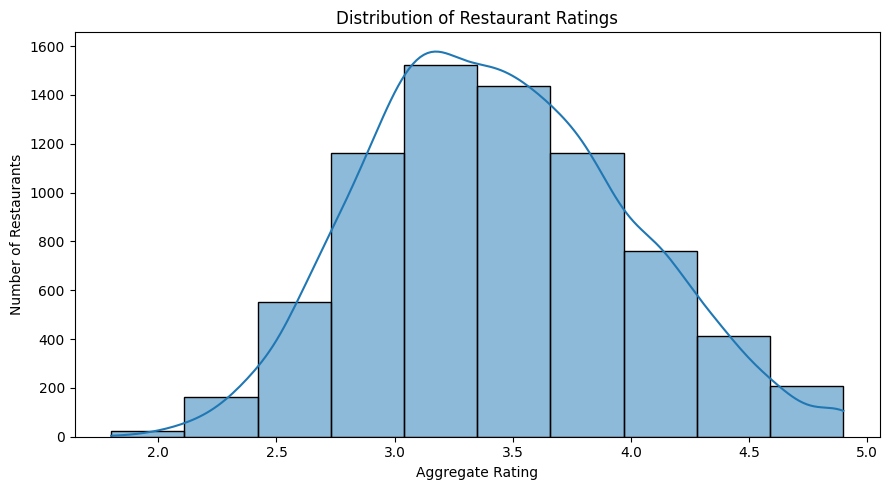

In [6]:
plt.figure(figsize=(9, 5))

sns.histplot(
    visual_df["Aggregate rating"],
    bins=10,
    kde=True
)

plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Aggregate Rating")
plt.ylabel("Number of Restaurants")

plt.tight_layout()
plt.show()

### Insight

The rating distribution shows how customer ratings are spread across
restaurants. This helps identify the most common rating range and
whether restaurants generally receive low, medium, or high ratings.

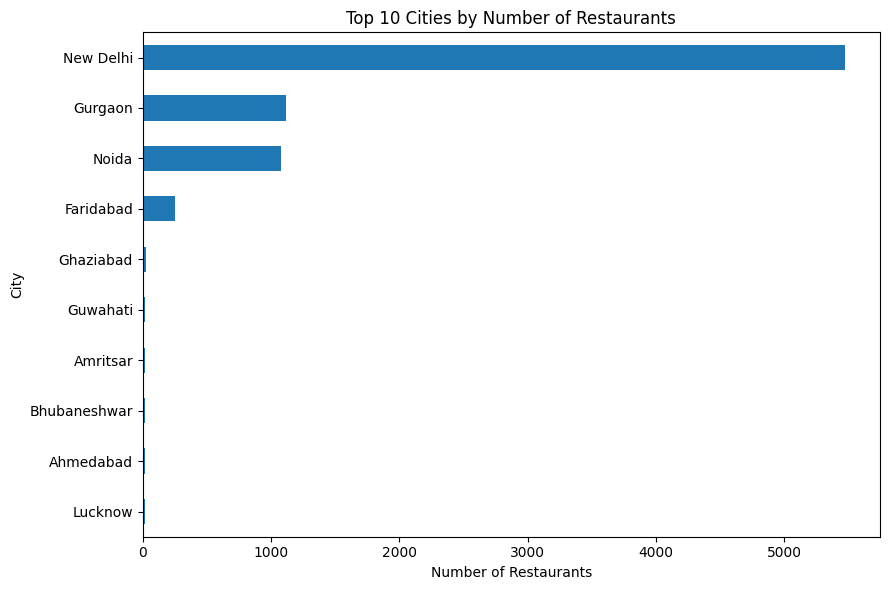

In [7]:
city_counts = (
    df["City"]
    .value_counts()
    .head(10)
    .sort_values()
)

plt.figure(figsize=(9, 6))

city_counts.plot(kind="barh")

plt.title("Top 10 Cities by Number of Restaurants")
plt.xlabel("Number of Restaurants")
plt.ylabel("City")

plt.tight_layout()
plt.show()

### Insight

The chart identifies the cities with the highest number of restaurants
in the dataset. These cities represent important restaurant markets
and can be useful for market analysis and business expansion decisions.

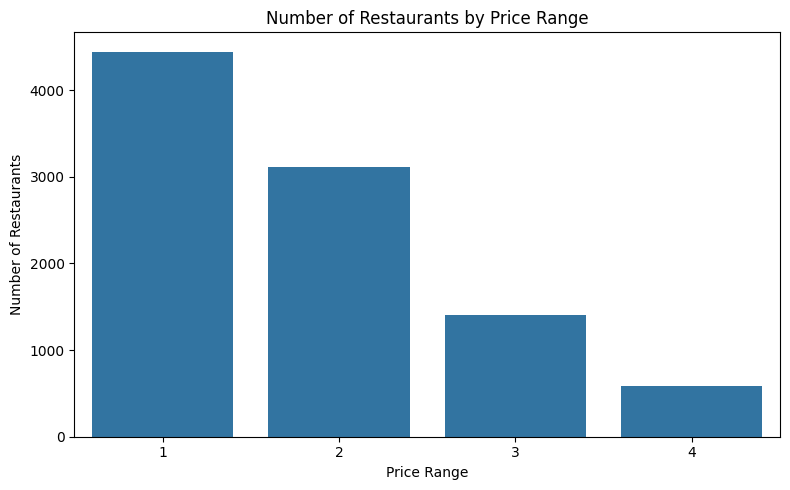

In [8]:
price_counts = df["Price range"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=price_counts.index,
    y=price_counts.values
)

plt.title("Number of Restaurants by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")

plt.tight_layout()
plt.show()

### Insight

The price-range visualization shows how restaurants are distributed
across different pricing categories. This can help understand the
dominant market segment and identify opportunities for restaurants
targeting specific customer budgets.

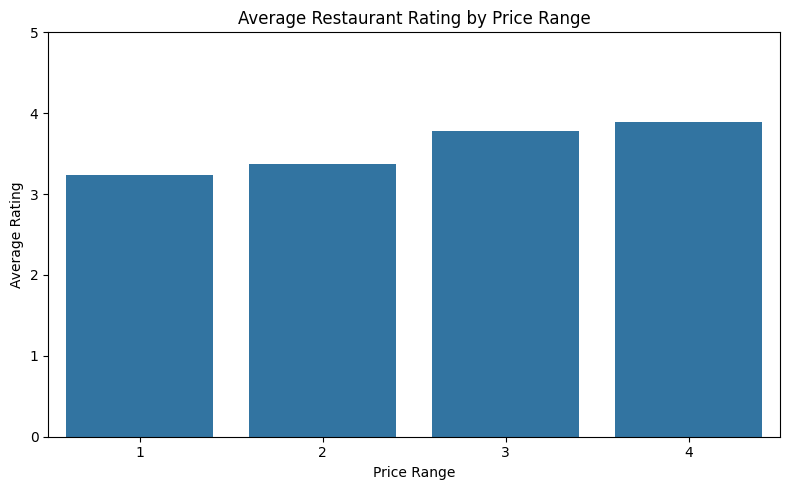

In [9]:
price_rating = (
    visual_df
    .groupby("Price range")["Aggregate rating"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=price_rating,
    x="Price range",
    y="Aggregate rating"
)

plt.title("Average Restaurant Rating by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Average Rating")

plt.ylim(0, 5)

plt.tight_layout()
plt.show()

### Insight

The visualization compares average restaurant ratings across different
price ranges. It helps identify whether higher-priced restaurants in
the dataset tend to have higher average customer ratings.

However, price alone cannot be considered the cause of a higher rating,
because factors such as cuisine, location, service, and customer
experience may also influence ratings.

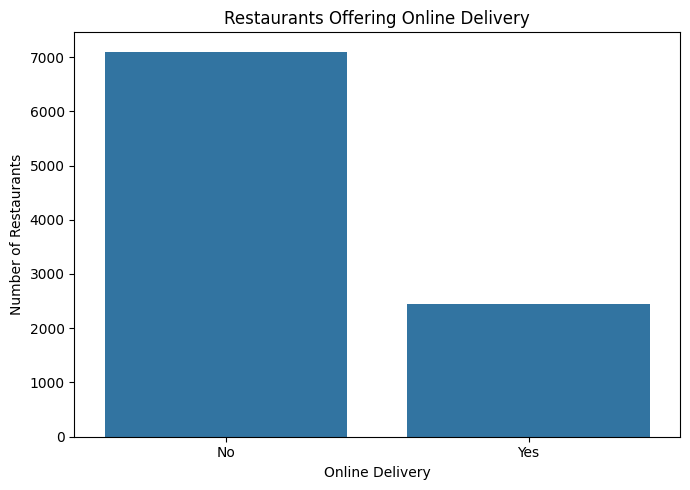

In [10]:
delivery_counts = df["Has Online delivery"].value_counts()

plt.figure(figsize=(7, 5))

sns.barplot(
    x=delivery_counts.index,
    y=delivery_counts.values
)

plt.title("Restaurants Offering Online Delivery")
plt.xlabel("Online Delivery")
plt.ylabel("Number of Restaurants")

plt.tight_layout()
plt.show()

### Insight

The chart compares restaurants that offer online delivery with those
that do not. This provides an overview of the adoption of online
delivery services among restaurants in the dataset.

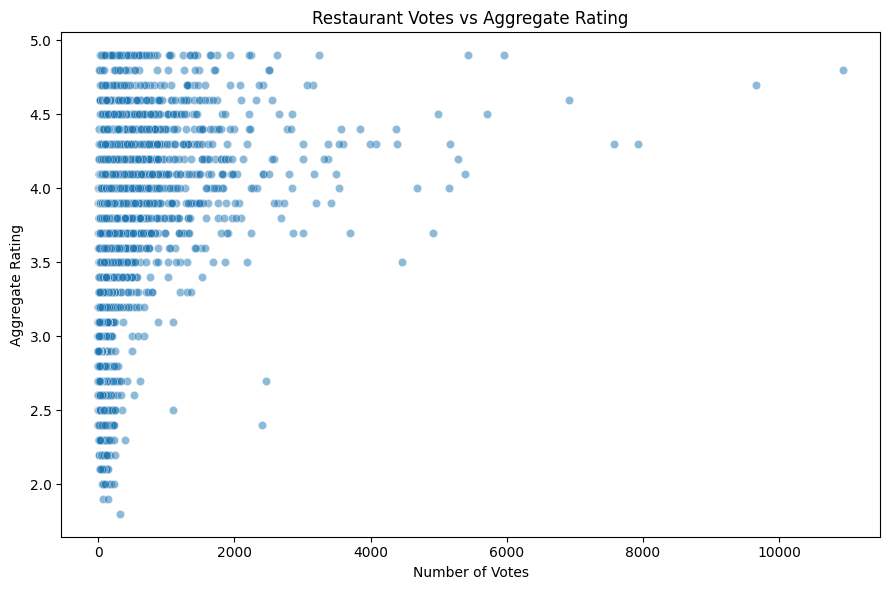

In [11]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=visual_df,
    x="Votes",
    y="Aggregate rating",
    alpha=0.5
)

plt.title("Restaurant Votes vs Aggregate Rating")
plt.xlabel("Number of Votes")
plt.ylabel("Aggregate Rating")

plt.tight_layout()
plt.show()

### Insight

The scatter plot compares the number of customer votes with restaurant
ratings. It helps identify whether restaurants receiving more customer
engagement also tend to have different rating patterns.

The relationship should not be interpreted as proof that votes cause
higher or lower ratings.

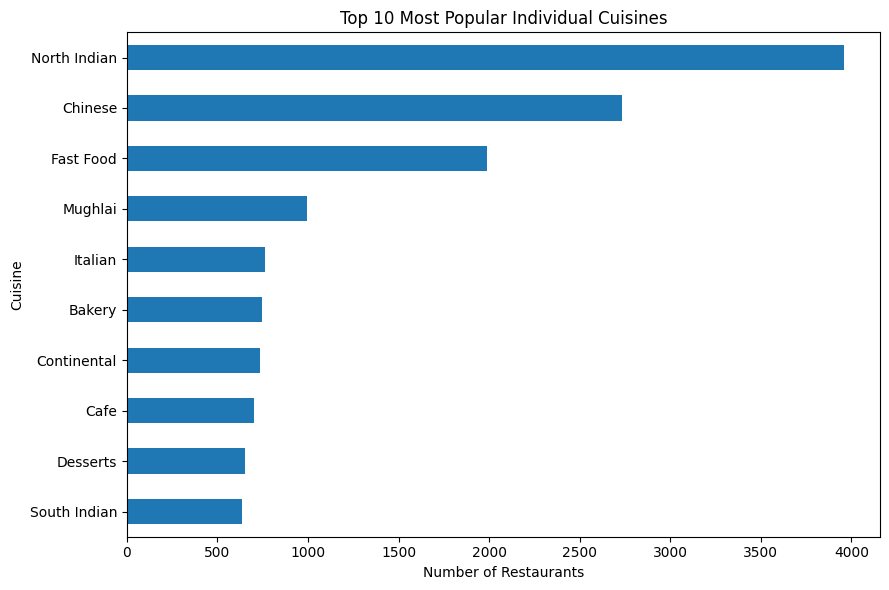

In [12]:
cuisine_series = (
    df["Cuisines"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
)

top_cuisines = cuisine_series.value_counts().head(10).sort_values()

plt.figure(figsize=(9, 6))

top_cuisines.plot(kind="barh")

plt.title("Top 10 Most Popular Individual Cuisines")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine")

plt.tight_layout()
plt.show()

cuisine_series = (
    df["Cuisines"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
)

top_cuisines = cuisine_series.value_counts().head(10).sort_values()

plt.figure(figsize=(9, 6))

top_cuisines.plot(kind="barh")

plt.title("Top 10 Most Popular Individual Cuisines")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine")

plt.tight_layout()
plt.show()

In [13]:
visual_df.to_csv(
    "task3_visualization_cleaned_data.csv",
    index=False
)

price_rating.to_csv(
    "task3_price_rating_analysis.csv",
    index=False
)

print("Task 3 files saved successfully!")

Task 3 files saved successfully!


# Conclusion

In this task, restaurant data was transformed into meaningful visual
representations using Pandas, Matplotlib, and Seaborn.

Different charts were created to analyze restaurant ratings, city-wise
restaurant distribution, price ranges, average ratings by price range,
online delivery availability, customer votes, and popular cuisines.

The visualizations make complex data easier to understand and reveal
patterns that can support business and decision-making activities.

This task demonstrated the practical application of data visualization
and data storytelling in analyzing real-world restaurant data.